# **Model-1: LFCC-LCNN using A-Softmax Loss**

## **Imports**


In [1]:
import os
import glob
import torchaudio
import torchaudio.transforms as T
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc
import scipy
from scipy.optimize import brentq 
from scipy.interpolate import interp1d

## **Main Configuration**

In [2]:
# --- Main Configuration ---
DATASET_BASE_DIR = '/kaggle/input/asvspoof-2019-la/ASVspoof2019_LA_wav'
PRECOMPUTED_BASE_DIR = '/kaggle/working/precomputed_lfcc'
TRAIN_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'train')
DEV_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'dev')
EVAL_OUTPUT_DIR = os.path.join(PRECOMPUTED_BASE_DIR, 'eval')

MODEL_SAVE_PATH = 'LFCC_LCNN_ASoftmax1.pth'

# Create output directories
os.makedirs(TRAIN_OUTPUT_DIR, exist_ok=True)
os.makedirs(DEV_OUTPUT_DIR, exist_ok=True)
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

# --- Paths ---
TRAIN_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.train.trn.txt')
DEV_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.dev.trl.txt')
EVAL_PROTOCOL = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.eval.trl.txt')

TRAIN_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_train', 'flac')
DEV_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_dev', 'flac')
EVAL_AUDIO_DIR = os.path.join(DATASET_BASE_DIR, 'ASVspoof2019_LA_eval', 'flac')

# --- Feature Parameters ---
SAMPLE_RATE = 16000
N_LFCC = 20 # Number of static coefficients
N_FEATURES = N_LFCC * 3 # 20 static + 20 delta + 20 delta-delta = 60
MAX_FRAMES = 600
WIN_LENGTH = int(0.020 * SAMPLE_RATE) # 320 samples
HOP_LENGTH = int(0.010 * SAMPLE_RATE) # 160 samples

# ---Other Parameters ---
NUM_CLASSES=2

# **LFCC Feature Extraction**

In [3]:
def extract_lfcc(audio_path, target_sr=SAMPLE_RATE):
    """
    Extracts 60-dimensional LFCC features following the Lavrentyeva et al. (2019)
    methodology for the ASVspoof 2019 challenge, using torchaudio.

    Args:
        audio_path (str): Path to the audio file.
        target_sr (int): Target sample rate. The ASVspoof 2019 dataset is 16 kHz.

    Returns:
        torch.Tensor: LFCC features with shape (1, 60, num_frames).
    """
    try:
        waveform, sample_rate = torchaudio.load(audio_path)
    except Exception as e:
        print(f"Error loading {audio_path}: {e}")
        return None
        
    if sample_rate != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)
        waveform = resampler(waveform)
    
    # convert to single channel and apply pre-emphasis
    waveform = waveform.mean(dim=0, keepdim=True)
    preemphasis_filter = T.Preemphasis(coeff=0.97)
    waveform = preemphasis_filter(waveform)

    # Compute LFCCs
    lfcc_transform = T.LFCC(
        sample_rate=target_sr,
        n_lfcc=N_LFCC,
        speckwargs={
            'n_fft': 512,
            'win_length': WIN_LENGTH,
            'hop_length': HOP_LENGTH,
            'power': 2.0
        }
    )
    lfccs = lfcc_transform(waveform)

    # Compute delta and delta-delta
    delta = T.ComputeDeltas(win_length=3)(lfccs)
    delta2 = T.ComputeDeltas(win_length=3)(delta)

    # Concatenate static, delta, and delta-delta
    full_lfccs = torch.cat((lfccs, delta, delta2), dim=1) # dim=1 to concatenate coefficients
    
    return full_lfccs

def process_and_save(file_path, audio_id, label, output_dir):
    """
    Loads audio, extracts LFCC features, and saves them to a .pt file.
    """
    try:
        # Extract features using the dedicated function
        lfcc_features = extract_lfcc(file_path)
        if lfcc_features is None:
            return None, None

        # Pad or truncate to MAX_FRAMES
        num_frames = lfcc_features.shape[2]  # Shape is (1,60,600)
        if num_frames > MAX_FRAMES:
            start_frame = (num_frames - MAX_FRAMES) // 2
            lfcc_features = lfcc_features[:, :, start_frame : start_frame + MAX_FRAMES]
        elif num_frames < MAX_FRAMES:
            padding = MAX_FRAMES - num_frames
            padding_left = padding // 2
            padding_right = padding - padding_left
            lfcc_features = torch.nn.functional.pad(lfcc_features, (padding_left, padding_right), "constant", 0)

        # Input shape from extract_lfcc is (1, 60, 600)
        # Transpose to (frames, features, channels)==(600, 60, 1) and unsqueeze channel dim
        lfcc_features = lfcc_features.squeeze(0).T.unsqueeze(-1)
        
        # Save the tensor and label
        file_info = {
            'features': lfcc_features.to(torch.float16),
            'label': torch.tensor(label, dtype=torch.long)
        }
        
        out_path = os.path.join(output_dir, audio_id + '.pt')
        torch.save(file_info, out_path)
        
        return audio_id, label
    except Exception as e:
        print(f"Error with {file_path}: {e}")
        return None, None

def parse_protocol(protocol_file, audio_dir):
    """    
    Parses protocol file and returns a list of tuples (file_path, audio_id, label).
    I had to first convert the entire dataset to .wav
    """
    file_info = []
    if not os.path.exists(protocol_file):
        print(f"Warning: Protocol file not found: {protocol_file}")
        return file_info
    
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split(' ')
            if len(parts) >= 5:
                audio_file_id = parts[1]
                file_path = os.path.join(audio_dir, audio_file_id + '.wav')
                if os.path.exists(file_path):
                    label = 1 if parts[4].lower() == 'spoof' else 0
                    file_info.append((file_path, audio_file_id, label))
                else:
                    print(f"Warning: Audio file not found: {file_path}")
            
    return file_info

def batch_extract_and_save(protocol_path, audio_dir, output_dir):
    """
    Main function to process and save a full dataset split in parallel.
    """
    print(f"Starting processing for {output_dir}...")
    file_info = parse_protocol(protocol_path, audio_dir)
    
    results = Parallel(n_jobs=-1)(
        delayed(process_and_save)(path, audio_id, label, output_dir)
        for path, audio_id, label in tqdm(file_info, desc=f"Saving to {output_dir}")
    )
    
    label_map = {audio_id: label for audio_id, label in results if audio_id is not None}
    label_path = os.path.join(output_dir, 'labels.pt')
    torch.save(label_map, label_path)
    
    print(f"Finished. Saved {len(label_map)} features and labels to: {output_dir}")



# Precomputation of LFCC features, saved to working directory as .pt files
if not os.path.exists(TRAIN_OUTPUT_DIR) or not os.listdir(TRAIN_OUTPUT_DIR):
    print("Precomputing training features...")
    batch_extract_and_save(TRAIN_PROTOCOL, TRAIN_AUDIO_DIR, TRAIN_OUTPUT_DIR)
else:
    print("Training features already precomputed.")

if not os.path.exists(DEV_OUTPUT_DIR) or not os.listdir(DEV_OUTPUT_DIR):
    print("Precomputing development features...")
    batch_extract_and_save(DEV_PROTOCOL, DEV_AUDIO_DIR, DEV_OUTPUT_DIR)
else:
    print("Development features already precomputed.")

if not os.path.exists(EVAL_OUTPUT_DIR) or not os.listdir(EVAL_OUTPUT_DIR):
    print("Precomputing evaluation features...")
    batch_extract_and_save(EVAL_PROTOCOL, EVAL_AUDIO_DIR, EVAL_OUTPUT_DIR)
else:
    print("Evaluation features already precomputed.")

Training features already precomputed.
Development features already precomputed.
Evaluation features already precomputed.


# **Model Definition**

## **Max-Feature-Map Activation and LCNN Model**

In [4]:
# Max Feature Map
class MaxFeatureMap(nn.Module):
    """
    Max-Feature-Map (MFM) activation layer for Conv layers.
    Splits along the channel dimension.
    """
    def __init__(self):
        super(MaxFeatureMap, self).__init__()
        
    def forward(self, x):
        # Splits the input tensor along the channel dimension (dim=1)
        x1, x2 = torch.split(x, x.size(1) // 2, dim=1)
        return torch.max(x1, x2)


# LCNN 
class LCNN(nn.Module):
    def __init__(self, sample_input_shape):
        super(LCNN, self).__init__()
        
        self.mfm = MaxFeatureMap()

        # --- LCNN Body (Convolutional Layers) ---
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(5, 5), padding='same')
        self.mp1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv4 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv7 = nn.Conv2d(32, 96, kernel_size=(3, 3), padding='same')
        self.mp2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.bn2 = nn.BatchNorm2d(48)
        self.conv11 = nn.Conv2d(48, 96, kernel_size=(1, 1), padding='same')
        self.bn3 = nn.BatchNorm2d(48)
        self.conv14 = nn.Conv2d(48, 128, kernel_size=(3, 3), padding='same')
        self.mp3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv17 = nn.Conv2d(64, 128, kernel_size=(1, 1), padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.conv20 = nn.Conv2d(64, 64, kernel_size=(3, 3), padding='same')
        self.bn5 = nn.BatchNorm2d(32)
        self.conv23 = nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same')
        self.bn6 = nn.BatchNorm2d(32)
        self.conv26 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding='same')
        self.mp4 = nn.MaxPool2d(kernel_size=(2, 2))

         # --- Dynamic Calculation of Input Size for Linear Layer ---
        dummy_input = torch.randn(1, 1, *sample_input_shape[:2])
        conv_output = self._forward_conv(dummy_input)
        flattened_size = conv_output.reshape(1, -1).size(1)
        print(f"Dynamically calculated flattened size based on real data: {flattened_size}")

        # --- Fully Connected (Linear) Layers ---
        self.fc29 = nn.Linear(flattened_size, 160)
        self.bn7 = nn.BatchNorm1d(80)
        self.dropout = nn.Dropout(p=0.75)

    def _forward_conv(self, x):
        """A helper function to pass data through the conv layers."""
        # This logic is identical to the forward pass, used for shape calculation
        x = self.mfm(self.conv1(x))
        x = self.mp1(x)
        x = self.mfm(self.conv4(x))
        x = self.bn1(x)
        x = self.mfm(self.conv7(x))
        x = self.mp2(x)
        x = self.mfm(self.conv11(x))
        x = self.bn3(x) 
        x = self.mfm(self.conv14(x))
        x = self.mp3(x)
        x = self.mfm(self.conv17(x))
        x = self.bn4(x)
        x = self.mfm(self.conv20(x))
        x = self.bn5(x)
        x = self.mfm(self.conv23(x))
        x = self.bn6(x)
        x = self.mfm(self.conv26(x))
        x = self.mp4(x)
        return x

    def forward(self, x):
        # The input from TensorFlow/Keras is (32, height, width, 1)
        # PyTorch Conv2d expects (32, 1, height, width)
        # The permute operation fixes this ordering.
        x = x.permute(0, 3, 1, 2)

        # Pass through all the convolutional layers
        x = self._forward_conv(x)
        
        # Flatten the tensor before the linear layer
        x = x.reshape(x.size(0), -1)

        # Pass through the first linear layer
        x = self.fc29(x)
        
        # --- MFM for Linear Layer ---
        # Output of fc29 is (32, 160). reshape to (32, 2, 80)
        x = x.view(x.size(0), 2, -1) 
        # Then take the max along the new dimension (dim=1)
        x = torch.max(x, dim=1)[0] # Shape becomes (32, 80)

        x = self.bn7(x)
        embeddings = self.dropout(x)
        return embeddings

## **A-Softmax Layer**

In [5]:
class ASoftmax(nn.Module):
    """
    A-Softmax layer with a trainable weight matrix.
    
    SphereFace: Deep Hypersphere Embedding for Face Recognition (CVPR '17)
    Weiyang Liu, Yandong Wen, Zhiding Yu, Ming Li, Bhiksha Raj, Le Song
    https://arxiv.org/abs/1704.08063
    
    Sourced and adapted from: https://github.com/phillity/metric_learning/blob/master/losses/angular_margin_loss/sphereface_loss.py
    """
    def __init__(self, in_features, num_classes, scale=30.0, margin=1.35):
        super(ASoftmax, self).__init__()
        self.in_features = in_features
        self.num_classes = num_classes
        self.scale = scale
        self.margin = margin

        self.W = nn.Parameter(torch.Tensor(in_features, num_classes))
        nn.init.kaiming_uniform_(self.W, a=2)

    def forward(self, embeddings, labels=None):
        # Normalise weights and embeddings
        W_norm = F.normalize(self.W, p=2, dim=0)
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        
        # Calculate cosine similarity (logits for inference)
        cosine_logits = embeddings_norm.mm(W_norm)
    
        # If no labels are provided (during evaluation), return the raw logits
        if labels is None:
            return cosine_logits
    
        # --- Training Path ---
        theta = torch.acos(torch.clamp(cosine_logits, -1.0 + 1e-7, 1.0 - 1e-7))
        one_hot = torch.zeros_like(cosine_logits)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        phi = theta * self.margin
        target_logits = torch.cos(phi)
        
        output = (one_hot * target_logits) + ((1.0 - one_hot) * cosine_logits)
        output *= self.scale
        
        return output

# **Model Training**

In [6]:
class LFCCDataset(Dataset):
    def __init__(self, data_dir):
        #directory where .pt files are saved
        self.data_dir = data_dir
        # find all files matching ".pt" in the directory
        self.file_list = glob.glob(os.path.join(data_dir, '*.pt'))
        # Exclude the labels.pt file (not a feature)
        self.file_list = [f for f in self.file_list if not os.path.basename(f).startswith('labels')]

    def __len__(self):
        # return num of samples in the dataset
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        # Load the dictionary saved with features and labels
        data = torch.load(file_path)
        # Extract the features tensor
        features = data['features']
        # Extract the label tensor
        label = data['label']
        # Return features and the label as a tuple
        return features.float(), label


#Check GPU Copmatibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# --- Data Loading ---
print("Loading datasets...")
train_dataset = LFCCDataset(TRAIN_OUTPUT_DIR)
dev_dataset = LFCCDataset(DEV_OUTPUT_DIR)
eval_dataset = LFCCDataset(EVAL_OUTPUT_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count())
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count())
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False, num_workers=os.cpu_count())


# --- Model---
print("Creating LCNN model with A-Softmax...")
# Get the shape of a single sample from the dataset
sample_features, _ = train_dataset[0] 
input_shape = sample_features.shape# The features have shape [600, 60, 1]
print(f"Sample input shape from dataset: {input_shape}")

# Define model architecture
lcnn_model = LCNN(input_shape).to(device)
a_softmax_layer = ASoftmax(in_features=80, num_classes=NUM_CLASSES).to(device)


Using device: cuda
Loading datasets...
Creating LCNN model with A-Softmax...
Sample input shape from dataset: torch.Size([600, 60, 1])
Dynamically calculated flattened size based on real data: 3552


In [7]:
# --- Loss and Optimizer ---
optimizer = optim.Adam(
    list(lcnn_model.parameters()) + list(a_softmax_layer.parameters()),
    lr=0.0001
)
criterion = nn.CrossEntropyLoss()

# --- Training Loop ---
num_epochs = 50
best_val_loss = float('inf')
patience_counter = 0
patience = 15
train_accuracy_history = []
train_loss_history =[]
val_loss_history = []
val_accuracy_history = []

print("Starting training...")
for epoch in range(num_epochs):
    lcnn_model.train()
    a_softmax_layer.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for features, labels in tqdm(train_loader, desc = f"Epoch {epoch+1}/{num_epochs} Training"):
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass: get embeddings from the LCNN
        embeddings = lcnn_model(features)
        
        # Get modified logits from the A-Softmax layer
        logits = a_softmax_layer(embeddings, labels)
        
        # Calculate the loss
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * features.size(0)
        # Calculate training accuracy for the batch
        # To get predictions, get the standard logits without the angular margin
        with torch.no_grad():
            logits_for_acc = a_softmax_layer(embeddings) 
            _, predicted = torch.max(logits_for_acc.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
    # Validation loop
    lcnn_model.eval()
    a_softmax_layer.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for features, labels in tqdm(dev_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation"):
            features, labels = features.to(device), labels.to(device)
            embeddings = lcnn_model(features)
            logits = a_softmax_layer(embeddings) 
            
            loss = criterion(logits, labels)
            val_loss += loss.item() * features.size(0)
            
            _, predicted = torch.max(logits.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate and print core metrics
    epoch_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = 100 * train_correct / train_total
    val_loss /= len(dev_dataset)
    val_accuracy = 100 * val_correct / val_total

    train_loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_train_accuracy)
    val_loss_history.append(val_loss)
    val_accuracy_history.append(val_accuracy)
    
    print(f'Epoch {epoch+1}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    # Early stopping and model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'lcnn_state_dict': lcnn_model.state_dict(),
            'a_softmax_state_dict': a_softmax_layer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
        }, 'LFCC_LCNN_ASoftmax1.pth')
        print(f"Model saved to 'LFCC_LCNN_ASoftmax1.pth' with new best validation loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break
print("Training finished.")

Starting training...


Epoch 1/50 Validation: 100%|██████████| 777/777 [00:21<00:00, 35.47it/s]


Epoch 1: Train Loss: 6.8855, Train Acc: 79.25%, Val Loss: 0.4528, Val Acc: 86.71%
Model saved to 'LFCC_LCNN_ASoftmax1.pth' with new best validation loss: 0.4528


Epoch 2/50 Validation: 100%|██████████| 777/777 [00:21<00:00, 35.62it/s]


Epoch 2: Train Loss: 2.3658, Train Acc: 93.20%, Val Loss: 0.2456, Val Acc: 99.15%
Model saved to 'LFCC_LCNN_ASoftmax1.pth' with new best validation loss: 0.2456


...

Epoch 48: Train Loss: 0.0767, Train Acc: 99.85%, Val Loss: 0.1722, Val Acc: 99.71%


Epoch 49/50 Validation: 100%|██████████| 777/777 [00:21<00:00, 35.37it/s]


Epoch 49: Train Loss: 0.0728, Train Acc: 99.85%, Val Loss: 0.1681, Val Acc: 99.73%
Model saved to 'LFCC_LCNN_ASoftmax1.pth' with new best validation loss: 0.1681


Epoch 50/50 Validation: 100%|██████████| 777/777 [00:22<00:00, 35.21it/s]

Epoch 50: Train Loss: 0.0685, Train Acc: 99.85%, Val Loss: 0.1694, Val Acc: 99.75%
Training finished.


## **Training and Validation Plots**

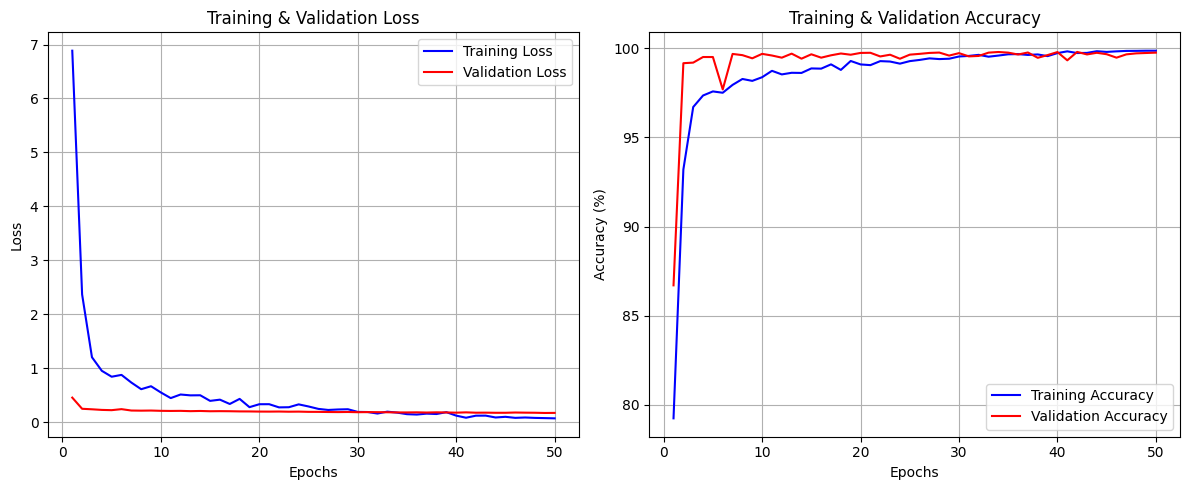

In [8]:
# Plotting the loss and accuracy curves
epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, 'b', label='Training Loss')
plt.plot(epochs, val_loss_history, 'r', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_history, 'b', label='Training Accuracy') 
plt.plot(epochs, val_accuracy_history, 'r', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Evaluating Model-1 on Development and Evaluation Sets**

In [9]:
def evaluate_model(model, asoftmax, data_loader, device, dataset_name="Dataset"):
    """
    Evaluates the model on a given dataset and prints performance metrics.
    
    Args:
        model (nn.Module): The LCNN model.
        asoftmax (nn.Module): The A-Softmax layer.
        data_loader (DataLoader): DataLoader for the dataset to evaluate.
        device (torch.device): The device to run evaluation on (e.g., 'cuda').
        dataset_name (str): A name for the dataset for clear printouts.
    """
    model.eval()
    asoftmax.eval()
    
    labels_list = []
    scores_list = []  
    preds_list = []

    #Features shape: torch.Size([32, 600, 60, 1])

    with torch.no_grad():
        for features, labels in tqdm(data_loader, desc=f"Evaluating on {dataset_name}"):
            features, labels = features.to(device), labels.to(device)
            embeddings = model(features)
            logits = asoftmax(embeddings)

            _, predicted = torch.max(logits.data, 1)
            softmax_scores = F.softmax(logits, dim=1)
            
            labels_list.extend(labels.cpu().numpy())
            scores_list.extend(softmax_scores[:, 1].cpu().numpy())
            preds_list.extend(predicted.cpu().numpy())

    # --- Calculate Metrics ---
    cm = confusion_matrix(labels_list, preds_list)
    f1 = f1_score(labels_list, preds_list)
    
    # EER is calculated from the raw scores
    fpr, tpr, _ = roc_curve(labels_list, scores_list, pos_label=1)
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.abs(fnr - fpr))
    eer = fpr[eer_index]

    print(f"\n--- Model Performance on {dataset_name} ---")
    print(f"Confusion Matrix:\n{cm}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Equal Error Rate (EER): {eer * 100:.2f}%")
    print("-" * 50)

    
    return {
        'fpr': fpr,
        'tpr': tpr,
        'eer': eer,
        'f1': f1,
        'cm': cm
    }

# **Plots**


## **ROC Curve plot**

In [10]:
def plot_roc_curve(results, model_name="Model-1"):
    """
    Plots the ROC curve using the results from the evaluate_model function.
    
    Args:
        results (dict): The dictionary returned by evaluate_model.
        model_name (str): A name for the model/dataset for the plot title.
    """
    # Get the fpr and tpr from the results dictionary
    fpr = results['fpr']
    tpr = results['tpr']
    
    # Compute Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

## **Feature Visualisation Function**

In [11]:
def display_random_lfccs(feature_dir, num_samples=6):
    """
    Loads and displays LFCC features for a specified number of random samples.
    
    Args:
        feature_dir (str): Path to the directory containing saved .pt feature files.
        num_samples (int): The number of random samples to display.
    """
    # Get a list of all .pt files in the directory
    all_files = [f for f in os.listdir(feature_dir) if f.endswith('.pt') and f != 'labels.pt']
    
    if len(all_files) < num_samples:
        print(f"Warning: Only found {len(all_files)} files, displaying all of them.")
        num_samples = len(all_files)
    
    # Randomly select a subset of files
    selected_files = random.sample(all_files, num_samples)
    
    # Create a figure with a grid of subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten() # Flatten the 2x3 array to easily iterate

    for i, file_name in enumerate(selected_files):
        file_path = os.path.join(feature_dir, file_name)
        try:
            # Load the saved dictionary
            data = torch.load(file_path)
            features = data['features']
            label = data['label'].item()

            # Convert tensor to numpy for plotting and remove the channel dimension
            features_np = features.squeeze().numpy()
            
            title_color = 'red' if label == 1 else 'green' if label == 0 else 'gray'
        
            # Plot on the current subplot
            im = axes[i].imshow(features_np.T, aspect='auto', origin='lower', cmap='magma')
            axes[i].set_title(f'Sample {i+1} - {"Spoof" if label == 1 else "Bonafide"}', color=title_color)
            axes[i].set_xlabel('Time (Frames)')
            axes[i].set_ylabel('LFCC Coefficient')
            
            # Add a colorbar for each subplot
            plt.colorbar(im, ax=axes[i], label='Amplitude')

        except Exception as e:
            print(f"Error displaying features from {file_path}: {e}")
            axes[i].set_title("Error loading file")
            axes[i].set_xticks([])
            axes[i].set_yticks([])

    plt.tight_layout()
    plt.show()


# **Main Execution**

Loaded best model from 'LFCC_LCNN_ASoftmax1.pth'.


Evaluating on Development Set: 100%|██████████| 777/777 [00:22<00:00, 35.13it/s]



--- Model Performance on Development Set ---
Confusion Matrix:
[[ 2487    61]
 [    7 22289]]
F1 Score: 0.9985
Equal Error Rate (EER): 0.71%
--------------------------------------------------


Evaluating on Evaluation Set: 100%|██████████| 2227/2227 [01:03<00:00, 35.17it/s]



--- Model Performance on Evaluation Set ---
Confusion Matrix:
[[ 7057   298]
 [ 5104 58778]]
F1 Score: 0.9561
Equal Error Rate (EER): 6.74%
--------------------------------------------------


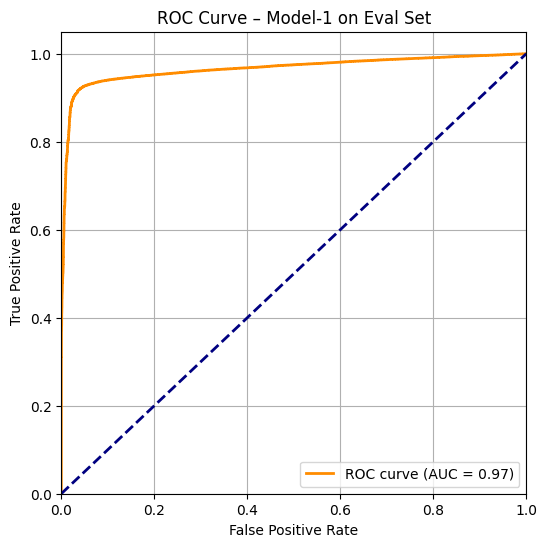

In [12]:
# --- Load Model and Run Evaluations ---
# Load the single best checkpoint
try:
    checkpoint_path = 'LFCC_LCNN_ASoftmax1.pth'
    checkpoint = torch.load(checkpoint_path)
    lcnn_model.load_state_dict(checkpoint['lcnn_state_dict'])
    a_softmax_layer.load_state_dict(checkpoint['a_softmax_state_dict'])
    print(f"Loaded best model from '{checkpoint_path}'.")
except FileNotFoundError:
    print(f"Error: Model checkpoint not found at '{checkpoint_path}'.")
    
    
# Evaluation for the Development set
dev_results = evaluate_model(
    lcnn_model, 
    a_softmax_layer, 
    dev_loader, 
    device, 
    dataset_name="Development Set"
)

# --- Evaluate and Plot for the Evaluation Set ---
eval_results = evaluate_model(
    lcnn_model, 
    a_softmax_layer, 
    eval_loader, 
    device, 
    dataset_name="Evaluation Set"
)

# Plot the results for the eval set
plot_roc_curve(eval_results, model_name="Model-1 on Eval Set")

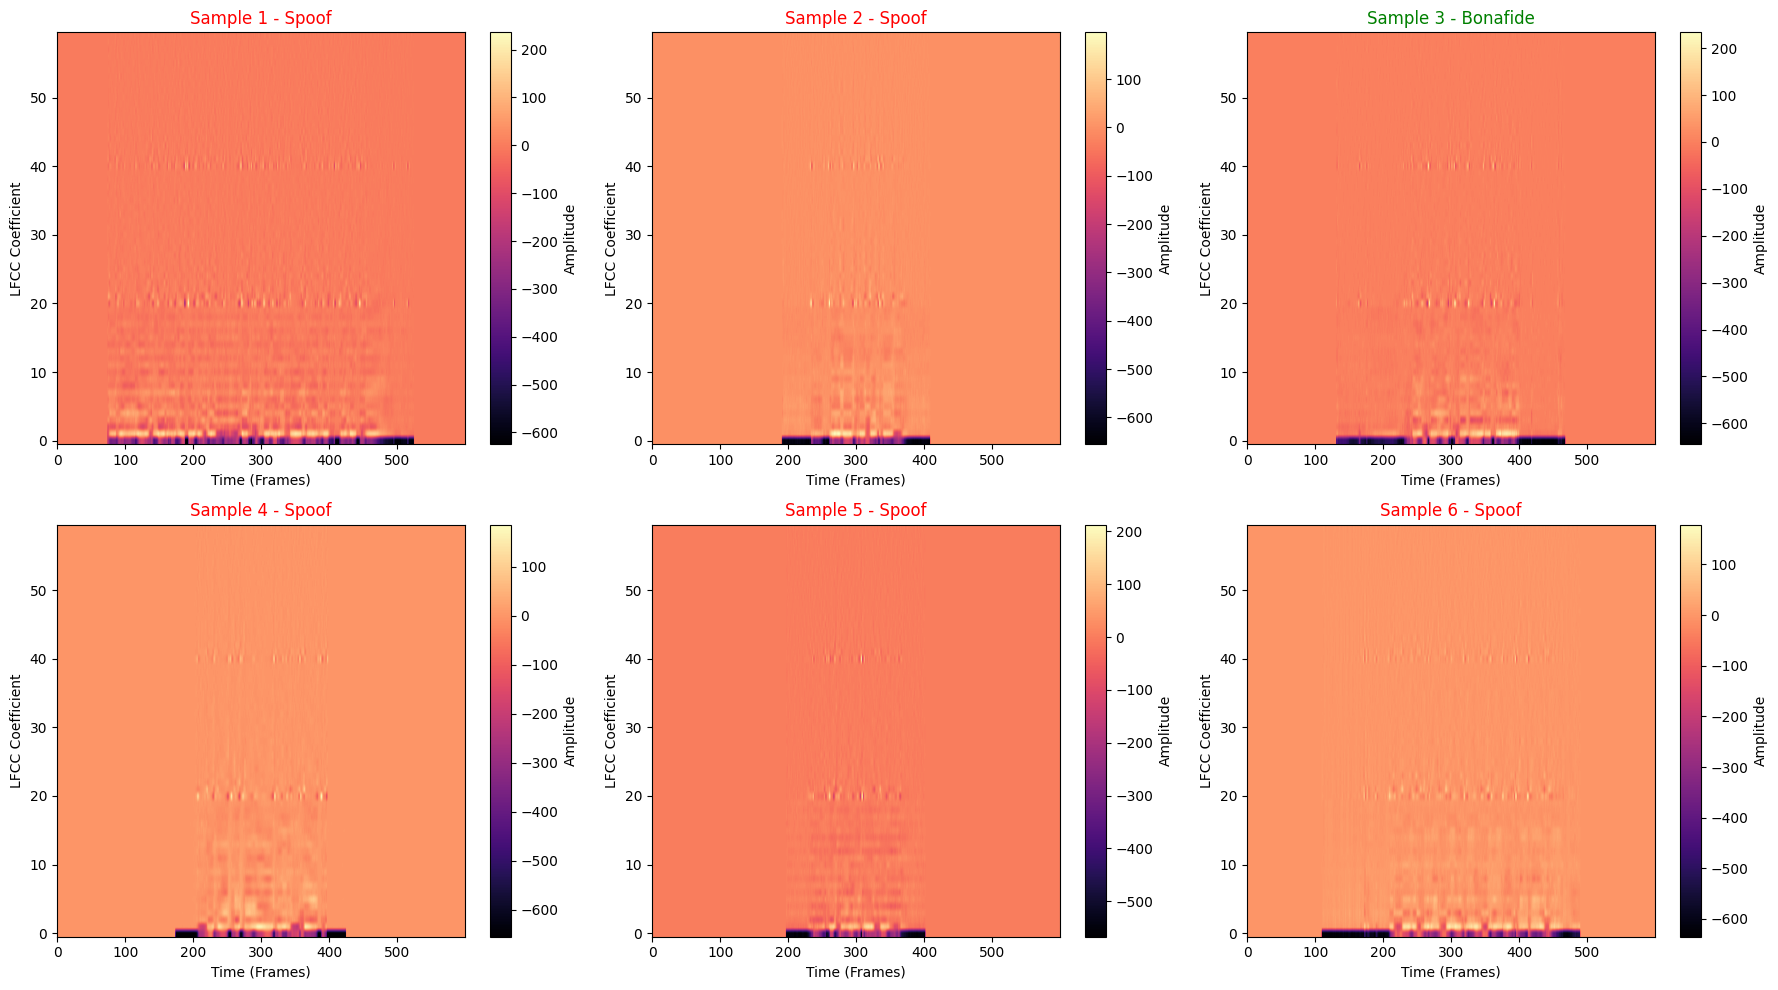

In [13]:
# Display random LFCC features extracted from the audio files
display_random_lfccs(TRAIN_OUTPUT_DIR)
